In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
nbs = pd.read_csv('E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\NewBiasDataset\\newsmediabias_plus_combined.csv')

In [3]:
nbs.head()

,unique_id,outlet_x,title,date_published_x,content,article_url,canonical_link_x,source_url_x,image_description_x,text_label_x,...,article_text,source_url_y,canonical_link_y,new_categories,news_categories_confidence_scores,text_label_y,multimodal_label_y,image_description_y,image_filename,image_path
0,39e6104d56,CBC.ca,"Tij Iginla embraces family name, eager to foll...",2024-06-24 14:48:00+00:00,Tij Iginla doesn't shy away from his famous la...,https://www.cbc.ca/news/canada/calgary/tij-igi...,https://www.cbc.ca/news/canada/calgary/tij-igi...,https://www.cbc.ca,A man with a bald head and a black suit is smi...,Likely,...,Tij Iginla doesn't shy away from his famous la...,https://www.cbc.ca,https://www.cbc.ca/news/canada/calgary/tij-igi...,['Sports' 'National'],[0.95 0.7 ],Likely,Unlikely,A man with a bald head and a black suit is smi...,39e6104d56.jpeg,C:\Users\ritik\Downloads\images\images\39e6104...
1,8b320e107e,CBC News,"Conservative MP shares inaccurate, ChatGPT-gen...",2024-06-24 18:01:00+00:00,An Ontario Conservative MP's use of ChatGPT to...,https://www.cbc.ca/news/politics/conservative-...,https://www.cbc.ca/news/politics/conservative-...,https://www.cbc.ca,A man in a blue suit stands in a room with yel...,Likely,...,An Ontario Conservative MP's use of ChatGPT to...,https://www.cbc.ca,https://www.cbc.ca/news/politics/conservative-...,['Politics' 'Business and Finance'],[0.85 0.75],Likely,Likely,A man in a blue suit stands in a room with yel...,8b320e107e.jpeg,C:\Users\ritik\Downloads\images\images\8b320e1...
2,7536f87654,CBC.ca,"Women's sports are more popular than ever, but...",2024-06-22 08:00:00+00:00,"When it comes to the study of sports, a man's ...",https://www.cbc.ca/news/canada/montreal/womens...,https://www.cbc.ca/news/canada/montreal/womens...,https://www.cbc.ca,"Two hockey players in action on the ice, one i...",Unlikely,...,"When it comes to the study of sports, a man's ...",https://www.cbc.ca,https://www.cbc.ca/news/canada/montreal/womens...,['Sports' 'Health'],[0.85 0.75],Unlikely,Unlikely,"Two hockey players in action on the ice, one i...",7536f87654.jpeg,C:\Users\ritik\Downloads\images\images\7536f87...
3,c829d1f9a8,CBC.ca,June 22: Listener Question Show - CBC.ca,2024-06-21 18:20:00+00:00,"To wrap up the 48th season of Quirks & Quarks,...",https://www.cbc.ca/radio/quirks/quirks-quarks-...,https://www.cbc.ca/radio/quirks/quirks-quarks-...,https://www.cbc.ca,A man with a thoughtful expression stands in f...,Likely,...,"To wrap up the 48th season of Quirks & Quarks,...",https://www.cbc.ca,https://www.cbc.ca/radio/quirks/quirks-quarks-...,['Science' 'Other'],[0.9 0.7],Likely,Unlikely,A man with a thoughtful expression stands in f...,c829d1f9a8.jpeg,C:\Users\ritik\Downloads\images\images\c829d1f...
4,a0ba0e377b,CBC.ca,Albertans can't legally gamble with Betway. So...,2024-06-21 21:18:00+00:00,When following the Edmonton Oilers' playoff ru...,https://www.cbc.ca/news/canada/betway-edmonton...,https://www.cbc.ca/news/canada/betway-edmonton...,https://www.cbc.ca,A hockey game is in progress with players from...,Likely,...,When following the Edmonton Oilers' playoff ru...,https://www.cbc.ca,https://www.cbc.ca/news/canada/betway-edmonton...,['Politics' 'Sports'],[0.85 0.8 ],Likely,Unlikely,A hockey game is in progress with players from...,a0ba0e377b.jpeg,C:\Users\ritik\Downloads\images\images\a0ba0e3...


In [4]:
nbs.columns

Index(['unique_id', 'outlet_x', 'title', 'date_published_x', 'content',
       'article_url', 'canonical_link_x', 'source_url_x',
       'image_description_x', 'text_label_x', 'multimodal_label_x', 'outlet_y',
       'headline', 'date_published_y', 'top_image', 'article_text',
       'source_url_y', 'canonical_link_y', 'new_categories',
       'news_categories_confidence_scores', 'text_label_y',
       'multimodal_label_y', 'image_description_y', 'image_filename',
       'image_path'],
      dtype='object')

In [5]:
nbs.dtypes

unique_id                            object
outlet_x                             object
title                                object
date_published_x                     object
content                              object
article_url                          object
canonical_link_x                     object
source_url_x                         object
image_description_x                  object
text_label_x                         object
multimodal_label_x                   object
outlet_y                             object
headline                             object
date_published_y                     object
top_image                            object
article_text                         object
source_url_y                         object
canonical_link_y                     object
new_categories                       object
news_categories_confidence_scores    object
text_label_y                         object
multimodal_label_y                   object
image_description_y             

In [6]:
nbs['multimodal_label_x'].unique()

array(['Unlikely', 'Likely'], dtype=object)

In [7]:
nbs['text_label_x'].unique()

array(['Likely', 'Unlikely'], dtype=object)

In [8]:
nbs['text_label_y'].unique()

array(['Likely', 'Unlikely'], dtype=object)

In [9]:
nbs.head()

,unique_id,outlet_x,title,date_published_x,content,article_url,canonical_link_x,source_url_x,image_description_x,text_label_x,...,article_text,source_url_y,canonical_link_y,new_categories,news_categories_confidence_scores,text_label_y,multimodal_label_y,image_description_y,image_filename,image_path
0,39e6104d56,CBC.ca,"Tij Iginla embraces family name, eager to foll...",2024-06-24 14:48:00+00:00,Tij Iginla doesn't shy away from his famous la...,https://www.cbc.ca/news/canada/calgary/tij-igi...,https://www.cbc.ca/news/canada/calgary/tij-igi...,https://www.cbc.ca,A man with a bald head and a black suit is smi...,Likely,...,Tij Iginla doesn't shy away from his famous la...,https://www.cbc.ca,https://www.cbc.ca/news/canada/calgary/tij-igi...,['Sports' 'National'],[0.95 0.7 ],Likely,Unlikely,A man with a bald head and a black suit is smi...,39e6104d56.jpeg,C:\Users\ritik\Downloads\images\images\39e6104...
1,8b320e107e,CBC News,"Conservative MP shares inaccurate, ChatGPT-gen...",2024-06-24 18:01:00+00:00,An Ontario Conservative MP's use of ChatGPT to...,https://www.cbc.ca/news/politics/conservative-...,https://www.cbc.ca/news/politics/conservative-...,https://www.cbc.ca,A man in a blue suit stands in a room with yel...,Likely,...,An Ontario Conservative MP's use of ChatGPT to...,https://www.cbc.ca,https://www.cbc.ca/news/politics/conservative-...,['Politics' 'Business and Finance'],[0.85 0.75],Likely,Likely,A man in a blue suit stands in a room with yel...,8b320e107e.jpeg,C:\Users\ritik\Downloads\images\images\8b320e1...
2,7536f87654,CBC.ca,"Women's sports are more popular than ever, but...",2024-06-22 08:00:00+00:00,"When it comes to the study of sports, a man's ...",https://www.cbc.ca/news/canada/montreal/womens...,https://www.cbc.ca/news/canada/montreal/womens...,https://www.cbc.ca,"Two hockey players in action on the ice, one i...",Unlikely,...,"When it comes to the study of sports, a man's ...",https://www.cbc.ca,https://www.cbc.ca/news/canada/montreal/womens...,['Sports' 'Health'],[0.85 0.75],Unlikely,Unlikely,"Two hockey players in action on the ice, one i...",7536f87654.jpeg,C:\Users\ritik\Downloads\images\images\7536f87...
3,c829d1f9a8,CBC.ca,June 22: Listener Question Show - CBC.ca,2024-06-21 18:20:00+00:00,"To wrap up the 48th season of Quirks & Quarks,...",https://www.cbc.ca/radio/quirks/quirks-quarks-...,https://www.cbc.ca/radio/quirks/quirks-quarks-...,https://www.cbc.ca,A man with a thoughtful expression stands in f...,Likely,...,"To wrap up the 48th season of Quirks & Quarks,...",https://www.cbc.ca,https://www.cbc.ca/radio/quirks/quirks-quarks-...,['Science' 'Other'],[0.9 0.7],Likely,Unlikely,A man with a thoughtful expression stands in f...,c829d1f9a8.jpeg,C:\Users\ritik\Downloads\images\images\c829d1f...
4,a0ba0e377b,CBC.ca,Albertans can't legally gamble with Betway. So...,2024-06-21 21:18:00+00:00,When following the Edmonton Oilers' playoff ru...,https://www.cbc.ca/news/canada/betway-edmonton...,https://www.cbc.ca/news/canada/betway-edmonton...,https://www.cbc.ca,A hockey game is in progress with players from...,Likely,...,When following the Edmonton Oilers' playoff ru...,https://www.cbc.ca,https://www.cbc.ca/news/canada/betway-edmonton...,['Politics' 'Sports'],[0.85 0.8 ],Likely,Unlikely,A hockey game is in progress with players from...,a0ba0e377b.jpeg,C:\Users\ritik\Downloads\images\images\a0ba0e3...


In [10]:
count = nbs['image_description_x'] == nbs['image_description_y']
count.value_counts()

True    31340
Name: count, dtype: int64

Removing the columns containing url and date

In [11]:
col = ['date_published_x','article_url','canonical_link_x','source_url_x','date_published_y','canonical_link_y','source_url_y']
nbs = nbs.drop(columns=col,axis=1)

In [12]:
nbs.columns

Index(['unique_id', 'outlet_x', 'title', 'content', 'image_description_x',
       'text_label_x', 'multimodal_label_x', 'outlet_y', 'headline',
       'top_image', 'article_text', 'new_categories',
       'news_categories_confidence_scores', 'text_label_y',
       'multimodal_label_y', 'image_description_y', 'image_filename',
       'image_path'],
      dtype='object')

In [13]:
"""
import os
from PIL import Image

def remove_corrupted_image(path,dataset):
    path_=path.replace('\\','/')
    try:
        with Image.open(path_) as img:
            img.verify() 
        return False 
    except (IOError, SyntaxError) as e:
        print(f"Removing corrupted image: {path_} - {e}")
        dataset = dataset.drop(dataset[dataset['image_path'] == path].index,inplace=True)
        return True 
"""

'\nimport os\nfrom PIL import Image\n\ndef remove_corrupted_image(path,dataset):\n    path_=path.replace(\'\\\',\'/\')\n    try:\n        with Image.open(path_) as img:\n            img.verify() \n        return False \n    except (IOError, SyntaxError) as e:\n        print(f"Removing corrupted image: {path_} - {e}")\n        dataset = dataset.drop(dataset[dataset[\'image_path\'] == path].index,inplace=True)\n        return True \n'

In [14]:
"""nbs['image_path'].apply(lambda x : remove_corrupted_image(x,nbs))"""

"nbs['image_path'].apply(lambda x : remove_corrupted_image(x,nbs))"

In [15]:
"""nbs = nbs.reset_index(drop=True)"""


'nbs = nbs.reset_index(drop=True)'

In [16]:
nbs.shape[0]

31340

In [17]:
"""nbs.to_csv('No_Corrupted_NBS.csv',index=False)"""

"nbs.to_csv('No_Corrupted_NBS.csv',index=False)"

In [18]:
nbs = pd.read_csv('E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\No_Corrupted_NBS.csv')

In [19]:
nbs.shape[0]

6249

In [20]:
nbs

,unique_id,outlet_x,title,content,image_description_x,text_label_x,multimodal_label_x,outlet_y,headline,top_image,article_text,new_categories,news_categories_confidence_scores,text_label_y,multimodal_label_y,image_description_y,image_filename,image_path
0,23400064a2,CBC.ca,Anishnabeg Outreach develops self-serve mental...,A new resource developed by Anishnabeg Outreac...,The image shows a person standing in front of ...,Unlikely,Likely,CBC.ca,Anishnabeg Outreach develops self-serve mental...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A new resource developed by Anishnabeg Outreac...,['Health' 'Local/Regional'],[0.85 0.75],Unlikely,Likely,The image shows a person standing in front of ...,23400064a2.jpeg,C:\Users\ritik\Downloads\images\images\2340006...
1,0bad329c25,CBC.ca,South Asian newcomers to Canada say online hat...,International student Miran Kadri had many thi...,Two individuals with backpacks walking on a ci...,Likely,Unlikely,CBC.ca,South Asian newcomers to Canada say online hat...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",International student Miran Kadri had many thi...,['National' 'Opinion/Editorial'],[0.85 0.65],Likely,Unlikely,Two individuals with backpacks walking on a ci...,0bad329c25.jpeg,C:\Users\ritik\Downloads\images\images\0bad329...
2,267f8bc361,CBC.ca,Program that pairs nurses with RCMP on mental ...,A program in Fort McMurray that pairs police o...,A smiling woman in a pink shirt is seated in a...,Unlikely,Likely,CBC.ca,Program that pairs nurses with RCMP on mental ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A program in Fort McMurray that pairs police o...,['Local/Regional' 'Health'],[0.85 0.75],Unlikely,Likely,A smiling woman in a pink shirt is seated in a...,267f8bc361.jpeg,C:\Users\ritik\Downloads\images\images\267f8bc...
3,2fab02aa42,CBC.ca,Should social media come with a health warning...,The U.S. surgeon general has called for social...,"A person is holding a smartphone, possibly rea...",Likely,Unlikely,CBC.ca,Should social media come with a health warning...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",The U.S. surgeon general has called for social...,['Health' 'Opinion/Editorial'],[0.9 0.7],Likely,Unlikely,"A person is holding a smartphone, possibly rea...",2fab02aa42.jpeg,C:\Users\ritik\Downloads\images\images\2fab02a...
4,004798d706,CBC.ca,Inside Out 2: What the movie’s 4 new emotions ...,"Emotions are clues about ourselves, says exper...",A character with blue hair and a green dress s...,Likely,Unlikely,CBC.ca,Inside Out 2: What the movie’s 4 new emotions ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","Emotions are clues about ourselves, says exper...",['Entertainment' 'Health'],[0.85 0.75],Likely,Unlikely,A character with blue hair and a green dress s...,004798d706.jpeg,C:\Users\ritik\Downloads\images\images\004798d...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6244,0471e108dd,CNN,Opinion: We Germans are making Trump ‘thunders...,Editor’s Note: Anna Sauerbrey is the foreign e...,A black and white photo of a large assembly ha...,Likely,Likely,CNN,Opinion: We Germans are making Trump ‘thunders...,"{'bytes': None, 'path': '/projects/NMB-Plus/wh...",Editor’s Note: Anna Sauerbrey is the foreign e...,['Opinion/Editorial' 'Politics'],[0.9 0.8],Likely,Likely,A black and white photo of a large assembly ha...,0471e108dd.jpg,C:\Users\ritik\Downloads\images\images\0471e10...
6245,1e9e145f6e,CNN,Brazil’s floods smashed through barriers desig...,Karine Pitana had just paid off the last insta...,An aerial view of a flooded road with a yellow...,Likely,Likely,CNN,Brazil’s floods smashed through barriers desig...,"{'bytes': None, 'path': '/projects/NMB-Plus/wh...",Karine Pitana had just paid off the last insta...,['Local/Regional' 'National'],[0.85 0.75],Likely,Likely,An aerial view of a flooded road with a yellow...,1e9e145f6e.jpg,C:\Users\ritik\Downloads\images\images\1e9e145...
6246,0bc2d5dd25,CNN,"In a city cut off from the w

In [21]:
nbs['multimodal_label_y']

0         Likely
1       Unlikely
2         Likely
3       Unlikely
4       Unlikely
          ...   
6244      Likely
6245      Likely
6246      Likely
6247      Likely
6248      Likely
Name: multimodal_label_y, Length: 6249, dtype: object

In [22]:
nbs[nbs['multimodal_label_x']!=nbs['multimodal_label_y']].value_counts().sum()

np.int64(0)

In [23]:
nbs['MultiModal_Label'] =nbs['multimodal_label_x']


In [24]:
nbs=nbs.drop(columns=['multimodal_label_x','multimodal_label_y'])

In [25]:
nbs.columns

Index(['unique_id', 'outlet_x', 'title', 'content', 'image_description_x',
       'text_label_x', 'outlet_y', 'headline', 'top_image', 'article_text',
       'new_categories', 'news_categories_confidence_scores', 'text_label_y',
       'image_description_y', 'image_filename', 'image_path',
       'MultiModal_Label'],
      dtype='object')

In [26]:
#Renaming the columns 

In [27]:
nbs['caption']=nbs['image_description_x']

In [28]:
nbs=nbs.drop(columns=['image_description_x','image_description_y'])

In [29]:
nbs.columns

Index(['unique_id', 'outlet_x', 'title', 'content', 'text_label_x', 'outlet_y',
       'headline', 'top_image', 'article_text', 'new_categories',
       'news_categories_confidence_scores', 'text_label_y', 'image_filename',
       'image_path', 'MultiModal_Label', 'caption'],
      dtype='object')

In [30]:
nbs['text_label_x']

0       Unlikely
1         Likely
2       Unlikely
3         Likely
4         Likely
          ...   
6244      Likely
6245      Likely
6246      Likely
6247      Likely
6248      Likely
Name: text_label_x, Length: 6249, dtype: object

In [31]:
nbs['text_label_y']

0       Unlikely
1         Likely
2       Unlikely
3         Likely
4         Likely
          ...   
6244      Likely
6245      Likely
6246      Likely
6247      Likely
6248      Likely
Name: text_label_y, Length: 6249, dtype: object

In [32]:
nbs['text_labels']=nbs['text_label_x'].apply(lambda x : 'biased' if x=='Likely' else 'non-biased')

In [33]:
nbs['MultiModal_Label']=nbs['MultiModal_Label'].apply(lambda x : 'biased' if x=='Likely' else 'non-biased')

In [34]:
nbs['text_labels']

0       non-biased
1           biased
2       non-biased
3           biased
4           biased
           ...    
6244        biased
6245        biased
6246        biased
6247        biased
6248        biased
Name: text_labels, Length: 6249, dtype: object

In [35]:
nbs=nbs.drop(columns=['text_label_x','text_label_y'])

In [36]:
nbs['Outlet'] = nbs['outlet_x']
nbs=nbs.drop(columns=['outlet_x','outlet_y'])

In [37]:
nbs.columns

Index(['unique_id', 'title', 'content', 'headline', 'top_image',
       'article_text', 'new_categories', 'news_categories_confidence_scores',
       'image_filename', 'image_path', 'MultiModal_Label', 'caption',
       'text_labels', 'Outlet'],
      dtype='object')

In [38]:
nbs['new_categories'].unique()

array(["['Health' 'Local/Regional']", "['National' 'Opinion/Editorial']",
       "['Local/Regional' 'Health']", "['Health' 'Opinion/Editorial']",
       "['Entertainment' 'Health']",
       "['Business and Finance' 'National']",
       "['Politics' 'International']", "['Politics' 'National']",
       "['Local/Regional' 'Weather and Environment']",
       "['Politics' 'Local/Regional']", "['National' 'Politics']",
       "['Local/Regional' 'National']", "['Other']",
       "['Entertainment' 'Other']", "['Politics' 'Health' 'Other']",
       "['Opinion/Editorial' 'Other']",
       "['Weather and Environment' 'Local/Regional']",
       "['Health' 'National']", "['Local/Regional' 'Politics']",
       "['Health' 'Weather and Environment']",
       "['Politics' 'Opinion/Editorial']",
       "['Politics' 'National' 'Entertainment']", "['Entertainment']",
       "['Politics' 'Health' 'National']",
       "['Opinion/Editorial' 'Entertainment']",
       "['Politics' 'Business and Finance']",
   

[]

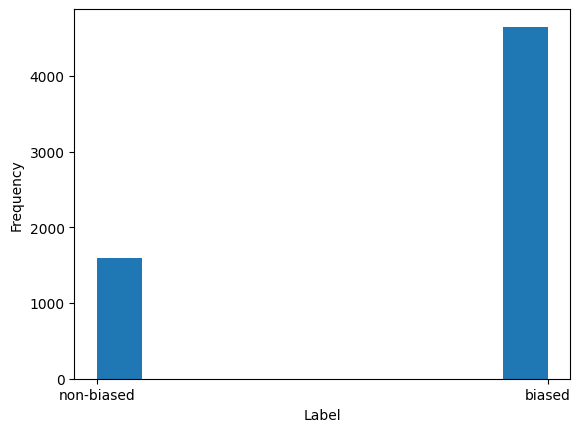

In [39]:
plt.hist(nbs['text_labels'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

[]

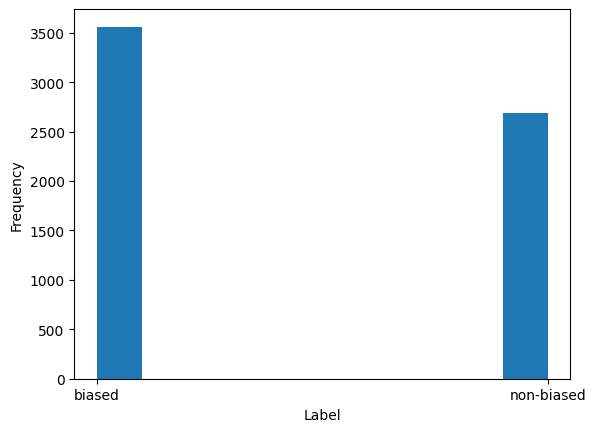

In [40]:
plt.hist(nbs['MultiModal_Label'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

In [41]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet
0,23400064a2,Anishnabeg Outreach develops self-serve mental...,A new resource developed by Anishnabeg Outreac...,Anishnabeg Outreach develops self-serve mental...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A new resource developed by Anishnabeg Outreac...,['Health' 'Local/Regional'],[0.85 0.75],23400064a2.jpeg,C:\Users\ritik\Downloads\images\images\2340006...,biased,The image shows a person standing in front of ...,non-biased,CBC.ca
1,0bad329c25,South Asian newcomers to Canada say online hat...,International student Miran Kadri had many thi...,South Asian newcomers to Canada say online hat...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",International student Miran Kadri had many thi...,['National' 'Opinion/Editorial'],[0.85 0.65],0bad329c25.jpeg,C:\Users\ritik\Downloads\images\images\0bad329...,non-biased,Two individuals with backpacks walking on a ci...,biased,CBC.ca
2,267f8bc361,Program that pairs nurses with RCMP on mental ...,A program in Fort McMurray that pairs police o...,Program that pairs nurses with RCMP on mental ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A program in Fort McMurray that pairs police o...,['Local/Regional' 'Health'],[0.85 0.75],267f8bc361.jpeg,C:\Users\ritik\Downloads\images\images\267f8bc...,biased,A smiling woman in a pink shirt is seated in a...,non-biased,CBC.ca
3,2fab02aa42,Should social media come with a health warning...,The U.S. surgeon general has called for social...,Should social media come with a health warning...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",The U.S. surgeon general has called for social...,['Health' 'Opinion/Editorial'],[0.9 0.7],2fab02aa42.jpeg,C:\Users\ritik\Downloads\images\images\2fab02a...,non-biased,"A person is holding a smartphone, possibly rea...",biased,CBC.ca
4,004798d706,Inside Out 2: What the movie’s 4 new emotions ...,"Emotions are clues about ourselves, says exper...",Inside Out 2: What the movie’s 4 new emotions ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","Emotions are clues about ourselves, says exper...",['Entertainment' 'Health'],[0.85 0.75],004798d706.jpeg,C:\Users\ritik\Downloads\images\images\004798d...,non-biased,A character with blue hair and a green dress s...,biased,CBC.ca


In [42]:
nbs['Outlet'].unique()

array(['CBC.ca', 'CBC News', 'Breitbart', 'Daily Caller',
       'The Federalist', 'Washington Examiner', 'Daily Kos',
       'The Daily Beast', 'National Review', 'Axios', 'ProPublica',
       'The New Yorker', 'The Atlantic', 'Newsweek', 'TIME',
       'Financial Times', 'The Economist', 'CNBC', 'HuffPost', 'Newsmax',
       'The Guardian', 'The Guardian US', 'PBS NewsHour',
       'Al Jazeera English', 'Bloomberg', 'Reuters', 'Forbes',
       'New York Post', 'POLITICO', 'The Associated Press', 'USA TODAY',
       'BBC.com', 'The Washington Post', 'The New York Times', 'ABC News',
       'CBS San Francisco', 'CBS Miami', 'CBS News', 'CBS Boston',
       'CBS New York', 'CBS Pittsburgh', 'CBS Chicago', 'Fox News', 'CNN',
       'CNN Underscored', 'National Post', 'The Globe and Mail',
       'Global News Toronto', 'Global News', 'Global News Kingston',
       'Global News Edmonton', 'Global News Guelph',
       'Global News Halifax', 'Global News Montréal',
       'Global News Barrie

In [43]:
count_biasedandnonbiased_wrt_outlets=nbs.groupby(nbs['MultiModal_Label'])['Outlet'].value_counts()

In [44]:
count_biasedandnonbiased_wrt_outlets

MultiModal_Label  Outlet                 
biased            Financial Times            475
                  USA TODAY                  322
                  The Guardian               304
                  CNN                        287
                  The New York Times         201
                                            ... 
non-biased        Global News Winnipeg         1
                  Golfweek                     1
                  Reuters India                1
                  The Wall Street Journal      1
                  USA Today                    1
Name: count, Length: 133, dtype: int64

In [45]:
nbs['Label_Match_Table']=nbs['MultiModal_Label']==nbs['text_labels']


In [46]:
nbs.groupby(['Label_Match_Table'])['Label_Match_Table'].value_counts()

Label_Match_Table
False    2707
True     3542
Name: count, dtype: int64

In [47]:
#Here we can see that the labels for text and image+text is different in more than half of the data

In [48]:
#It would be really better if we input the model for both the text and multimodal labels are we can see that the images are also biased so there is a difference in the bias labels for the multimodal prediction

In [49]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,23400064a2,Anishnabeg Outreach develops self-serve mental...,A new resource developed by Anishnabeg Outreac...,Anishnabeg Outreach develops self-serve mental...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A new resource developed by Anishnabeg Outreac...,['Health' 'Local/Regional'],[0.85 0.75],23400064a2.jpeg,C:\Users\ritik\Downloads\images\images\2340006...,biased,The image shows a person standing in front of ...,non-biased,CBC.ca,False
1,0bad329c25,South Asian newcomers to Canada say online hat...,International student Miran Kadri had many thi...,South Asian newcomers to Canada say online hat...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",International student Miran Kadri had many thi...,['National' 'Opinion/Editorial'],[0.85 0.65],0bad329c25.jpeg,C:\Users\ritik\Downloads\images\images\0bad329...,non-biased,Two individuals with backpacks walking on a ci...,biased,CBC.ca,False
2,267f8bc361,Program that pairs nurses with RCMP on mental ...,A program in Fort McMurray that pairs police o...,Program that pairs nurses with RCMP on mental ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A program in Fort McMurray that pairs police o...,['Local/Regional' 'Health'],[0.85 0.75],267f8bc361.jpeg,C:\Users\ritik\Downloads\images\images\267f8bc...,biased,A smiling woman in a pink shirt is seated in a...,non-biased,CBC.ca,False
3,2fab02aa42,Should social media come with a health warning...,The U.S. surgeon general has called for social...,Should social media come with a health warning...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",The U.S. surgeon general has called for social...,['Health' 'Opinion/Editorial'],[0.9 0.7],2fab02aa42.jpeg,C:\Users\ritik\Downloads\images\images\2fab02a...,non-biased,"A person is holding a smartphone, possibly rea...",biased,CBC.ca,False
4,004798d706,Inside Out 2: What the movie’s 4 new emotions ...,"Emotions are clues about ourselves, says exper...",Inside Out 2: What the movie’s 4 new emotions ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","Emotions are clues about ourselves, says exper...",['Entertainment' 'Health'],[0.85 0.75],004798d706.jpeg,C:\Users\ritik\Downloads\images\images\004798d...,non-biased,A character with blue hair and a green dress s...,biased,CBC.ca,False


In [50]:
len(nbs['Outlet'].unique())


78

In [51]:
nbs['Outlet'].value_counts()

Outlet
Financial Times       878
USA TODAY             508
The Guardian          479
CNN                   468
The New York Times    409
                     ... 
Golfweek                1
CBS Los Angeles         1
Global News London      1
Global News Regina      1
Economist Impact        1
Name: count, Length: 78, dtype: int64

In [52]:
dataset_for_plotting_text_labels = nbs[['text_labels','Outlet']]
dataset_for_plotting_MultiModal_Label = nbs[['MultiModal_Label','Outlet']]

In [53]:
dataset_for_plotting_MultiModal_Label.head()


,MultiModal_Label,Outlet
0,biased,CBC.ca
1,non-biased,CBC.ca
2,biased,CBC.ca
3,non-biased,CBC.ca
4,non-biased,CBC.ca


In [54]:
dataset_for_plotting_MultiModal_Label.shape[0]

6249

In [55]:
dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet'] == 'CBC.ca']

,MultiModal_Label,Outlet
0,biased,CBC.ca
1,non-biased,CBC.ca
2,biased,CBC.ca
3,non-biased,CBC.ca
4,non-biased,CBC.ca
5,non-biased,CBC.ca
8,non-biased,CBC.ca
9,non-biased,CBC.ca
11,non-biased,CBC.ca
14,non-biased,CBC.ca


In [56]:
for i in dataset_for_plotting_MultiModal_Label['Outlet'].unique():
    dataset_for_plotting_MultiModal_Label = dataset_for_plotting_MultiModal_Label.groupby('Outlet').filter(lambda x: len(x) >= 100)


In [57]:
for i in dataset_for_plotting_text_labels['Outlet'].unique():
    dataset_for_plotting_text_labels = dataset_for_plotting_text_labels.groupby('Outlet').filter(lambda x: len(x) >= 100)


In [58]:
dataset_for_plotting_MultiModal_Label.shape[0]

5545

In [59]:
len(dataset_for_plotting_MultiModal_Label['Outlet'].unique())

19

In [60]:

dataset_for_plotting_text_labels

,text_labels,Outlet
71,biased,National Review
72,biased,National Review
73,biased,National Review
74,biased,National Review
75,biased,National Review
...,...,...
6244,biased,CNN
6245,biased,CNN
6246,biased,CNN
6247,biased,CNN


[]

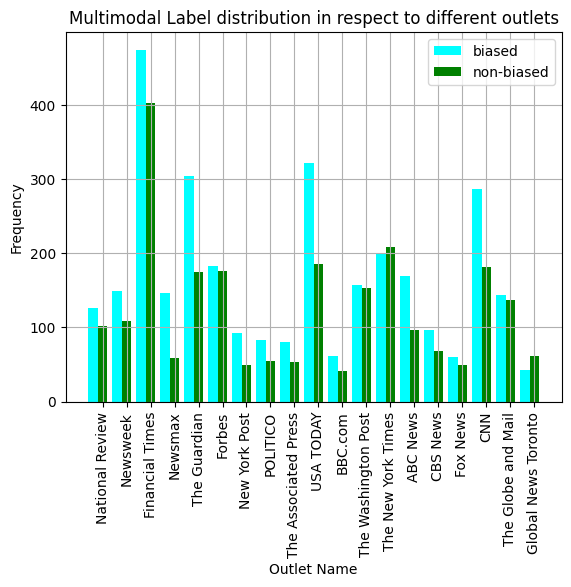

In [61]:

x= np.arange(19)
topic=dataset_for_plotting_MultiModal_Label['Outlet'].unique()
width=0.4
for i in x:
    plt.bar(i-0.4, (dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet']==topic[i]]['MultiModal_Label'] == 'biased').sum(), width, color='cyan')
    plt.bar(i, (dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet']==topic[i]]['MultiModal_Label'] == 'non-biased').sum(), width, color='green')
plt.xticks(x,topic,rotation='vertical')
plt.legend(nbs['MultiModal_Label'].unique())
plt.xlabel('Outlet Name')
plt.ylabel('Frequency')
plt.title('Multimodal Label distribution in respect to different outlets')
plt.grid(True)
plt.plot()

[]

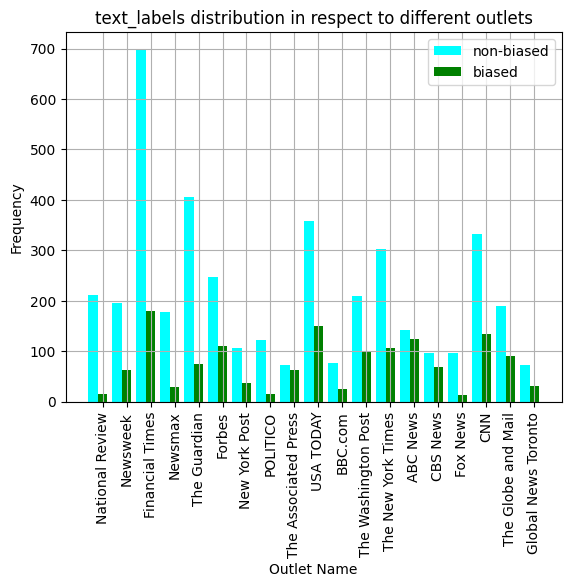

In [62]:
x= np.arange(19)
topic=dataset_for_plotting_text_labels['Outlet'].unique()
width=0.4
for i in x:
    plt.bar(i-0.4, (dataset_for_plotting_text_labels[dataset_for_plotting_text_labels['Outlet']==topic[i]]['text_labels'] == 'biased').sum(), width, color='cyan')
    plt.bar(i, (dataset_for_plotting_text_labels[dataset_for_plotting_text_labels['Outlet']==topic[i]]['text_labels'] == 'non-biased').sum(), width, color='green')
plt.xticks(x,topic,rotation='vertical')
plt.legend(nbs['text_labels'].unique())
plt.xlabel('Outlet Name')
plt.ylabel('Frequency')
plt.title('text_labels distribution in respect to different outlets')
plt.grid(True)
plt.plot()

nbs.columns

Removing non words 

In [63]:
nbs['article_text'] = nbs['article_text'].replace(to_replace=r'[^\w\s]', value='', regex=True)
nbs['caption'] = nbs['caption'].replace(to_replace=r'[^\w\s]', value='', regex=True)


Lower casing the text

In [64]:
nbs = nbs.applymap(lambda x: x.lower() if isinstance(x, str) else x)


C:\Users\ritik\AppData\Local\Temp\ipykernel_19780\3422254871.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  nbs = nbs.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [65]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,23400064a2,anishnabeg outreach develops self-serve mental...,a new resource developed by anishnabeg outreac...,anishnabeg outreach develops self-serve mental...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a new resource developed by anishnabeg outreac...,['health' 'local/regional'],[0.85 0.75],23400064a2.jpeg,c:\users\ritik\downloads\images\images\2340006...,biased,the image shows a person standing in front of ...,non-biased,cbc.ca,False
1,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,non-biased,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
2,267f8bc361,program that pairs nurses with rcmp on mental ...,a program in fort mcmurray that pairs police o...,program that pairs nurses with rcmp on mental ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a program in fort mcmurray that pairs police o...,['local/regional' 'health'],[0.85 0.75],267f8bc361.jpeg,c:\users\ritik\downloads\images\images\267f8bc...,biased,a smiling woman in a pink shirt is seated in a...,non-biased,cbc.ca,False
3,2fab02aa42,should social media come with a health warning...,the u.s. surgeon general has called for social...,should social media come with a health warning...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the us surgeon general has called for social m...,['health' 'opinion/editorial'],[0.9 0.7],2fab02aa42.jpeg,c:\users\ritik\downloads\images\images\2fab02a...,non-biased,a person is holding a smartphone possibly read...,biased,cbc.ca,False
4,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,non-biased,a character with blue hair and a green dress s...,biased,cbc.ca,False


In [66]:
nbs.describe()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
count,6249,6249,6249,6249,6249,6249,6249,6249,6249,6249,6249,6249,6249,6249,6249
unique,6249,6248,6249,6248,6249,6249,450,189,6249,6249,2,6144,2,77,2
top,075600b516,business books: what to read this month - fina...,netanyahu says biden made a mistake in delayin...,business books: what to read this month - fina...,"{'bytes': none, 'path': '/projects/nmb-plus/wh...",netanyahu says biden made a mistake in delayin...,['politics' 'national'],[0.95 0.85],075600b516.jpg,c:\users\ritik\downloads\images\images\075600b...,biased,the new york times logo centered on a black ba...,biased,financial times,True
freq,1,2,1,2,1,1,1843,1534,1,1,3562,51,4649,878,3542


In [67]:
nbs.isna().sum()

unique_id                            0
title                                0
content                              0
headline                             0
top_image                            0
article_text                         0
new_categories                       0
news_categories_confidence_scores    0
image_filename                       0
image_path                           0
MultiModal_Label                     0
caption                              0
text_labels                          0
Outlet                               0
Label_Match_Table                    0
dtype: int64

In [68]:
nbs.shape[0]

6249

In [69]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,23400064a2,anishnabeg outreach develops self-serve mental...,a new resource developed by anishnabeg outreac...,anishnabeg outreach develops self-serve mental...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a new resource developed by anishnabeg outreac...,['health' 'local/regional'],[0.85 0.75],23400064a2.jpeg,c:\users\ritik\downloads\images\images\2340006...,biased,the image shows a person standing in front of ...,non-biased,cbc.ca,False
1,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,non-biased,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
2,267f8bc361,program that pairs nurses with rcmp on mental ...,a program in fort mcmurray that pairs police o...,program that pairs nurses with rcmp on mental ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a program in fort mcmurray that pairs police o...,['local/regional' 'health'],[0.85 0.75],267f8bc361.jpeg,c:\users\ritik\downloads\images\images\267f8bc...,biased,a smiling woman in a pink shirt is seated in a...,non-biased,cbc.ca,False
3,2fab02aa42,should social media come with a health warning...,the u.s. surgeon general has called for social...,should social media come with a health warning...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the us surgeon general has called for social m...,['health' 'opinion/editorial'],[0.9 0.7],2fab02aa42.jpeg,c:\users\ritik\downloads\images\images\2fab02a...,non-biased,a person is holding a smartphone possibly read...,biased,cbc.ca,False
4,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,non-biased,a character with blue hair and a green dress s...,biased,cbc.ca,False


In [70]:
nbs['image_path'][1].replace('\\','/')

'c:/users/ritik/downloads/images/images/0bad329c25.jpeg'

In [71]:
#This dataset shows that the multimodal bias distribution has a leaning towards being biased a little biased.And we can also see that text labels and multimodal labels differ a bit and it can also be infered that the images affect the bias classification of the article .
#

In [72]:
nbs.columns

Index(['unique_id', 'title', 'content', 'headline', 'top_image',
       'article_text', 'new_categories', 'news_categories_confidence_scores',
       'image_filename', 'image_path', 'MultiModal_Label', 'caption',
       'text_labels', 'Outlet', 'Label_Match_Table'],
      dtype='object')

In [73]:
nbs['new_categories']

0             ['health' 'local/regional']
1        ['national' 'opinion/editorial']
2             ['local/regional' 'health']
3          ['health' 'opinion/editorial']
4              ['entertainment' 'health']
                      ...                
6244     ['opinion/editorial' 'politics']
6245        ['local/regional' 'national']
6246         ['national' 'international']
6247    ['international' 'entertainment']
6248         ['politics' 'international']
Name: new_categories, Length: 6249, dtype: object

In [74]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,23400064a2,anishnabeg outreach develops self-serve mental...,a new resource developed by anishnabeg outreac...,anishnabeg outreach develops self-serve mental...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a new resource developed by anishnabeg outreac...,['health' 'local/regional'],[0.85 0.75],23400064a2.jpeg,c:\users\ritik\downloads\images\images\2340006...,biased,the image shows a person standing in front of ...,non-biased,cbc.ca,False
1,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,non-biased,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
2,267f8bc361,program that pairs nurses with rcmp on mental ...,a program in fort mcmurray that pairs police o...,program that pairs nurses with rcmp on mental ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a program in fort mcmurray that pairs police o...,['local/regional' 'health'],[0.85 0.75],267f8bc361.jpeg,c:\users\ritik\downloads\images\images\267f8bc...,biased,a smiling woman in a pink shirt is seated in a...,non-biased,cbc.ca,False
3,2fab02aa42,should social media come with a health warning...,the u.s. surgeon general has called for social...,should social media come with a health warning...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the us surgeon general has called for social m...,['health' 'opinion/editorial'],[0.9 0.7],2fab02aa42.jpeg,c:\users\ritik\downloads\images\images\2fab02a...,non-biased,a person is holding a smartphone possibly read...,biased,cbc.ca,False
4,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,non-biased,a character with blue hair and a green dress s...,biased,cbc.ca,False


In [75]:
nbs.isna().sum()

unique_id                            0
title                                0
content                              0
headline                             0
top_image                            0
article_text                         0
new_categories                       0
news_categories_confidence_scores    0
image_filename                       0
image_path                           0
MultiModal_Label                     0
caption                              0
text_labels                          0
Outlet                               0
Label_Match_Table                    0
dtype: int64

In [76]:
nbs['MultiModal_Label'] = nbs['MultiModal_Label'].apply(lambda x: 1 if x == 'biased' else 0)

In [77]:
nbs['MultiModal_Label'].describe()

count    6249.000000
mean        0.570011
std         0.495114
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: MultiModal_Label, dtype: float64

In [78]:
nbs.shape[0]


6249

In [79]:
nbs_ = nbs


'''Change the quntity of data'''

In [80]:
nbs=nbs_.iloc[:3999]

In [81]:
nbs

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,23400064a2,anishnabeg outreach develops self-serve mental...,a new resource developed by anishnabeg outreac...,anishnabeg outreach develops self-serve mental...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a new resource developed by anishnabeg outreac...,['health' 'local/regional'],[0.85 0.75],23400064a2.jpeg,c:\users\ritik\downloads\images\images\2340006...,1,the image shows a person standing in front of ...,non-biased,cbc.ca,False
1,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,0,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
2,267f8bc361,program that pairs nurses with rcmp on mental ...,a program in fort mcmurray that pairs police o...,program that pairs nurses with rcmp on mental ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a program in fort mcmurray that pairs police o...,['local/regional' 'health'],[0.85 0.75],267f8bc361.jpeg,c:\users\ritik\downloads\images\images\267f8bc...,1,a smiling woman in a pink shirt is seated in a...,non-biased,cbc.ca,False
3,2fab02aa42,should social media come with a health warning...,the u.s. surgeon general has called for social...,should social media come with a health warning...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the us surgeon general has called for social m...,['health' 'opinion/editorial'],[0.9 0.7],2fab02aa42.jpeg,c:\users\ritik\downloads\images\images\2fab02a...,0,a person is holding a smartphone possibly read...,biased,cbc.ca,False
4,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,0,a character with blue hair and a green dress s...,biased,cbc.ca,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,30a2f492bd,'not going back': kamala harris voters at geor...,"cumming, ga. - ursula mather, a life-long demo...",'not going back': kamala harris voters at geor...,"{'bytes': none, 'path': '/projects/nmb-plus/wh...",cumming ga ursula mather a lifelong democrat ...,['politics' 'national'],[0.95 0.85],30a2f492bd.jpg,c:\users\ritik\downloads\images\images\30a2f49...,1,a woman stands at a podium with a microphone i...,biased,usa today,True
3995,308eec4b4e,'it was their rocket': u.s. blames hezbollah f...,washington – the white house said monday the i...,'it was their rocket': u.s. blames hezbollah f...,"{'bytes': none, 'path': '/projects/nmb-plus/wh...",washington the white house said monday the ir...,['international' 'politics'],[0.9 0.8],308eec4b4e.jpg,c:\users\ritik\downloads\images\images\308eec4...,0,an aerial view of a residential area with buil...,biased,usa today,False
3996,25f9365ceb,"archery could be a party in paris olympics, an...",paris — the les invalides is a historic landma...,"archery could be a party in paris olympics, an...","{'bytes': none, 'path': '/projects/nmb-plus/wh...",paris the les invalides is a historic landmar...,['sports' 'national'],[0.95 0.75],25f9365ceb.jpg,c:\users\ritik\downloads\images\images\25f9365...,1,an archer with an american flag shirt and a ca...,non-biased,usa today,False
3997,17b71feebc,will harris clinch the democratic nomination? ...,washington – vice president kamala harris is c...,will harris clinch the democratic nomination? ...,"{'byte

In [82]:
nbs_text_and_image = nbs.drop(columns=['unique_id'])

Train Test Split

In [83]:

X_train, X_test = train_test_split(nbs, test_size=0.3, random_state=42, stratify=nbs['MultiModal_Label'])


Function for Data Processing

In [84]:
#def Data_Processing(Dataset,Multilabel_column):
    

Importing the pretrained multimodal model from huggin face that is trained on NBS+ Dataset

Ref : https://huggingface.co/maximuspowers/multimodal-bias-classifier

In [85]:
import torch
from torch import nn
from transformers import BertModel,AutoModel
from huggingface_hub import hf_hub_download
from typing import Literal
import json

class MultimodalClassifier(nn.Module):
    def __init__(
            self,
            text_encoder_id_or_path: str,
            image_encoder_id_or_path: str,
            projection_dim: int,
            fusion_method: Literal["concat", "align", "cosine_similarity"] = "concat",
            proj_dropout: float = 0.1,
            fusion_dropout: float = 0.1,
            num_classes: int = 2,
        ) -> None:
        super().__init__()

        self.fusion_method = fusion_method
        self.projection_dim = projection_dim
        self.num_classes = num_classes

        ##### Text Encoder
        self.text_encoder = BertModel.from_pretrained(text_encoder_id_or_path)
        self.text_projection = nn.Sequential(
            nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Image Encoder (using ResNet34 from AutoModel with timm)
        self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
        self.image_encoder.classifier = nn.Identity()  # rm the classification head
        self.image_projection = nn.Sequential(
            nn.Linear(512, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Fusion Layer
        fusion_input_dim = self.projection_dim * 2 if fusion_method == "concat" else self.projection_dim
        self.fusion_layer = nn.Sequential(
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_input_dim, self.projection_dim),
            nn.GELU(),
            nn.Dropout(fusion_dropout),
        )

        ##### Classification Layer
        self.classifier = nn.Linear(self.projection_dim, self.num_classes)

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        ##### Text Encoder Projection #####
        full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
        full_text_features = full_text_features[:, 0, :]  # using cls token
        full_text_features = self.text_projection(full_text_features)

        ##### Image Encoder Projection #####
        resnet_image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state
        
        # global average pooling for resent image features (bad idea? dim problems)
        resnet_image_features = resnet_image_features.mean(dim=[-2, -1])
        resnet_image_features = self.image_projection(resnet_image_features)

        ##### Fusion and Classification #####
        if self.fusion_method == "concat":
            fused_features = torch.cat([full_text_features, resnet_image_features], dim=-1)
        else:
            fused_features = full_text_features * resnet_image_features # don't think this works atm (should be dot prod)

        # fusion and classifier layers
        fused_features = self.fusion_layer(fused_features)
        classification_output = self.classifier(fused_features)

        return classification_output

def load_model():
    
    config = {
        "model_type": "multimodal-bias-classifier", 
        "text_encoder_id_or_path": "E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\Model_config", 
        "image_encoder_id_or_path": "resnet34", 
        "projection_dim": 768, 
        "fusion_method": "concat", 
        "num_classes": 1, "proj_dropout": 0.1, 
        "fusion_dropout": 0.1, "hidden_size": 768, 
        "save_components": ["resnet_encoder", "text_encoder", "fusion_layer", "classifier"], 
        "exclude_components": ["clip_text_encoder", "clip_image_encoder"]}
    model = MultimodalClassifier(
        text_encoder_id_or_path=config["text_encoder_id_or_path"],
        image_encoder_id_or_path="microsoft/resnet-34",
        projection_dim=config["projection_dim"],
        fusion_method=config["fusion_method"],
        proj_dropout=config["proj_dropout"],
        fusion_dropout=config["fusion_dropout"],
        num_classes=config["num_classes"]
    )

    model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
    checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint, strict=False)

    return model


c:\Users\ritik\anaconda3\envs\datascience310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Declaring Tokenizer

In [86]:
import torch
from transformers import AutoTokenizer
from PIL import Image
import requests
from torchvision import transforms

model = load_model()
model.eval()





Some weights of BertModel were not initialized from the model checkpoint at E:\GitHub\Multi-Model-Bias-Detection-and-Debiasing-the-News\EDA\Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [87]:
print(model)

MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [88]:
import torchinfo

torchinfo.summary(model, col_names = ["num_params", "params_percent", "trainable"], depth = 4, row_settings = ["var_names"], verbose = 1);


Layer (type (var_name))                                                     Param #                   Param %                   Trainable
MultimodalClassifier (MultimodalClassifier)                                 --                             --                   True
├─BertModel (text_encoder)                                                  --                             --                   True
│    └─BertEmbeddings (embeddings)                                          --                             --                   True
│    │    └─Embedding (word_embeddings)                                     23,440,896                 25.93%                   True
│    │    └─Embedding (position_embeddings)                                 393,216                     0.43%                   True
│    │    └─Embedding (token_type_embeddings)                               1,536                       0.00%                   True
│    │    └─LayerNorm (LayerNorm)                               

In [89]:
model.classifier

Linear(in_features=768, out_features=1, bias=True)

In [90]:
device = torch.device(device = "cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

Dataloader

In [91]:
text_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [92]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class DATA(Dataset):
    def __init__(self, dataframe, text_tokenizer, image_transform):
        self.df = dataframe
        self.text_tokenizer = text_tokenizer
        self.image_transform = image_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['article_text']
        image_path = row['image_path']

        # tokenize text
        text_inputs = self.text_tokenizer(
            text, padding='max_length', truncation=True, max_length=512 , return_tensors='pt'
        )
        # transform image
        image = Image.open(image_path).convert('RGB')
        image_input = self.image_transform(image)

        #label = torch.tensor(row['MultiModal_Label'])
        
        input_ids= text_inputs['input_ids'][0]
        attention_mask= text_inputs['attention_mask']
        pixel_values = image_input
        labels =  int(row['MultiModal_Label'])
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'pixel_values': image_input,
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Then create dataset and loader

train_loader_dataset = DATA(X_train, text_tokenizer, image_transform)
test_loader_dataset = DATA(X_test, text_tokenizer, image_transform)

training_loader = DataLoader(train_loader_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(test_loader_dataset, batch_size=4, shuffle=True)

In [93]:
train_loader_dataset

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [94]:
import torch
torch.cuda.empty_cache()

In [95]:
from tqdm import tqdm

loss_function = torch.nn.BCEWithLogitsLoss()
LEARNING_RATE=2e-5




def calcuate_accuracy(preds, targets):
    n_correct = (preds==targets).sum().item()
    return n_correct

def calculate_truth_value(preds,targets):
    n_True_pos = ((preds==targets)&(targets==1)).sum().item()
    n_False_pos = ((preds!=targets)&(targets==0)).sum().item()
    n_True_neg = ((preds==targets)&(targets==0)).sum().item()
    n_False_neg = ((preds!=targets)&(targets==1)).sum().item()
    return n_True_pos,n_False_pos,n_True_neg,n_False_neg

def train(epoch, training_loader,LEARNING_RATE=2e-5):

    optimizer = torch.optim.Adam(params =  model.parameters(), lr=LEARNING_RATE)

    tr_loss = 0
    n_correct = 0
    nb_tr_steps = 0
    nb_tr_examples = 0
    True_pos= 0 
    False_pos=0
    True_neg=0
    False_neg=0
    n_True_pos=0;n_False_pos=0;n_True_neg=0;n_False_neg=0
    model.train()
    for _,data in tqdm(enumerate(training_loader, 0)):
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        pixel_values = data['pixel_values'].to(device, dtype = torch.float)
        targets = data['labels'][:, None].to(device, dtype = torch.float)

        outputs = model(input_ids=ids,
            attention_mask=mask,
            pixel_values=pixel_values)
        loss = loss_function(outputs, targets)
        tr_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5        
        n_correct += calcuate_accuracy(preds, targets.bool())

        n_True_pos,n_False_pos,n_True_neg,n_False_neg = calculate_truth_value(preds, targets.bool())
        True_pos += n_True_pos
        False_pos += n_False_pos
        True_neg += n_True_neg
        False_neg += n_False_neg

        nb_tr_steps += 1
        nb_tr_examples+=targets.size(0)
        
        if _%500==0:
            loss_step = tr_loss/nb_tr_steps
            accu_step = (n_correct*100)/nb_tr_examples 

        optimizer.zero_grad()
        loss.backward()
        # # When using GPU
        optimizer.step()

    print(f'The Total Accuracy for Epoch {epoch}: {(n_correct*100)/nb_tr_examples}')
    epoch_loss = tr_loss/nb_tr_steps
    epoch_accu = (n_correct*100)/nb_tr_examples

    return model
 



def valid(model, testing_loader):
    model.eval()
    n_correct = 0; n_wrong = 0; total = 0; tr_loss=0; nb_tr_steps=0; nb_tr_examples=0 ; True_pos=0; False_pos=0; True_neg=0; False_neg=0; n_True_pos=0;n_False_pos=0;n_True_neg=0;n_False_neg=0

    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            pixel_values = data['pixel_values'].to(device, dtype = torch.float)
            targets = data['labels'].reshape(-1,1).to(device, dtype = torch.float)

            outputs = model(input_ids=ids,
            attention_mask=mask,
            pixel_values=pixel_values)

            loss = loss_function(outputs, targets)
            tr_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5        
            n_correct += calcuate_accuracy(preds, targets.bool())

            n_True_pos,n_False_pos,n_True_neg,n_False_neg = calculate_truth_value(preds, targets)
            True_pos += n_True_pos
            False_pos += n_False_pos
            True_neg += n_True_neg
            False_neg += n_False_neg


            nb_tr_steps += 1
            nb_tr_examples+=targets.size(0)
            
            if _%5000==0:
                loss_step = tr_loss/nb_tr_steps
                accu_step = (n_correct*100)/nb_tr_examples

        labels = ["Biased", "Not Biased"]  

    for i in range(len(preds)):
        predicted_class = int(preds[i].item())  
        predicted_label = labels[predicted_class]
        predicted_prob = torch.sigmoid(outputs[i]).item()
        print(f"Prediction: {predicted_label}, Probability: {predicted_prob:.4f}")

    epoch_loss = tr_loss/nb_tr_steps
    epoch_accu = (n_correct*100)/nb_tr_examples
    print(f"Validation Loss Epoch: {epoch_loss}")
    print(f"Validation Accuracy Epoch: {epoch_accu}")
    
    return epoch_accu,True_pos,False_pos,True_neg,False_neg

#https://stackoverflow.com/questions/62301674/extracting-labels-after-applying-softmax  --> For Probability, Weights and Labels

In [96]:
'''Trained Model'''


EPOCHS = 1
for epoch in range(EPOCHS):
    train(epoch, training_loader)

    
acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg = valid(model, val_loader)
print("Accuracy on validation data = %0.2f%%" % acc)


print(f"aCCURACY {acc}")
print(f'True Positives : {n_True_pos}')
print(f'n_False_pos : {n_False_pos}')
print(f'n_True_neg : {n_True_neg}')
print(f'n_False_neg : {n_False_neg}')


0it [00:00, ?it/s]C:\Users\ritik\AppData\Local\Temp\ipykernel_19780\2097003488.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),
C:\Users\ritik\AppData\Local\Temp\ipykernel_19780\2097003488.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
700it [58:36,  5.02s/it]


The Total Accuracy for Epoch 0: 55.76991782779564


300it [05:31,  1.11s/it]

Prediction: Not Biased, Probability: 0.5720
Prediction: Not Biased, Probability: 0.5853
Prediction: Not Biased, Probability: 0.6005
Prediction: Not Biased, Probability: 0.5920
Validation Loss Epoch: 0.6806203082203865
Validation Accuracy Epoch: 56.333333333333336
Accuracy on validation data = 56.33%
aCCURACY 56.333333333333336
True Positives : 664
n_False_pos : 516
n_True_neg : 12
n_False_neg : 8


In [97]:
'''Model Saved after Training'''

torch.save(model.state_dict(), "fine_tuned_model_nbs.pt")


In [98]:
dict=torch.load("fine_tuned_model_nbs.pt")


In [99]:
model = load_model()
model.load_state_dict(dict)
model.eval()

Some weights of BertModel were not initialized from the model checkpoint at E:\GitHub\Multi-Model-Bias-Detection-and-Debiasing-the-News\EDA\Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [112]:
def eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg):                                      
    recall_deno = n_True_pos+n_False_neg                               
    recall = n_True_pos/recall_deno
    print(recall)

    Precision_dino = n_True_pos + n_False_pos                                                                                                                                                  
    Precision = n_True_pos/Precision_dino             
    print(Precision)                                                                                            
    F1_dino = Precision+recall
    F1_num= 2*Precision*recall
    F1= F1_num/F1_dino
    print(F1)

    return F1

In [113]:
'''eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)'''

'eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)'

Optimization

In [114]:

X_train_opt, X_test_opt = train_test_split(nbs_.iloc[4000:4999], test_size=0.3, random_state=42, stratify=nbs_.iloc[4000:4999]['MultiModal_Label'])


In [115]:
import sys
!{sys.executable} -m pip install hyperopt

In [126]:
from hyperopt import hp

space = {
    'LEARNING_RATE': hp.quniform('LEARNING_RATE', 1e-6, 5e-5, 1e-6),
    'batch_size': hp.choice('batch_size', [2, 4]),
    'epoch': hp.choice('epoch', [1, 2]),
    'fusion_type' : hp.choice('fusion_type',["concat", "align", "cosine_similarity"])
}


In [127]:
def obj_func(params):
    try:

        """Parameter"""

        fusion_type = params['fusion_type']
        batch_size = params['batch_size']
        epochs = int(params['epoch'])
        LEARNING_RATE = params['LEARNING_RATE']

        """Model Declaration"""

        class MultimodalClassifier(nn.Module):
            def __init__(
                    self,
                    text_encoder_id_or_path: str,
                    image_encoder_id_or_path: str,
                    projection_dim: int,
                    fusion_method: Literal["concat", "align", "cosine_similarity"] = fusion_type,
                    proj_dropout: float = 0.1,
                    fusion_dropout: float = 0.1,
                    num_classes: int = 2,
                ) -> None:
                super().__init__()

                self.fusion_method = fusion_method
                self.projection_dim = projection_dim
                self.num_classes = num_classes

                ##### Text Encoder
                self.text_encoder = BertModel.from_pretrained(text_encoder_id_or_path)
                self.text_projection = nn.Sequential(
                    nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
                    nn.Dropout(proj_dropout),
                )

                ##### Image Encoder (using ResNet34 from AutoModel with timm)
                self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
                self.image_encoder.classifier = nn.Identity()  # rm the classification head
                self.image_projection = nn.Sequential(
                    nn.Linear(512, self.projection_dim),
                    nn.Dropout(proj_dropout),
                )

                ##### Fusion Layer
                fusion_input_dim = self.projection_dim * 2 if fusion_method == fusion_type else self.projection_dim
                self.fusion_layer = nn.Sequential(
                    nn.Dropout(fusion_dropout),
                    nn.Linear(fusion_input_dim, self.projection_dim),
                    nn.GELU(),
                    nn.Dropout(fusion_dropout),
                )

                ##### Classification Layer
                self.classifier = nn.Linear(self.projection_dim, self.num_classes)

            def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
                ##### Text Encoder Projection #####
                full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
                full_text_features = full_text_features[:, 0, :]  # using cls token
                full_text_features = self.text_projection(full_text_features)

                ##### Image Encoder Projection #####
                resnet_image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state
                
                # global average pooling for resent image features (bad idea? dim problems)
                resnet_image_features = resnet_image_features.mean(dim=[-2, -1])
                resnet_image_features = self.image_projection(resnet_image_features)

                ##### Fusion and Classification #####
                if self.fusion_method == "concat":
                    fused_features = torch.cat([full_text_features, resnet_image_features], dim=-1)
                else:
                    fused_features = full_text_features * resnet_image_features # don't think this works atm (should be dot prod)

                # fusion and classifier layers
                fused_features = self.fusion_layer(fused_features)
                classification_output = self.classifier(fused_features)

                return classification_output

            def load_model():
                config = {
                    "model_type": "multimodal-bias-classifier", 
                    "text_encoder_id_or_path": "E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\Model_config", 
                    "image_encoder_id_or_path": "resnet34", 
                    "projection_dim": 768, 
                    "fusion_method": "concat", 
                    "num_classes": 1, "proj_dropout": 0.1, 
                    "fusion_dropout": 0.1, "hidden_size": 768, 
                    "save_components": ["resnet_encoder", "text_encoder", "fusion_layer", "classifier"], 
                    "exclude_components": ["clip_text_encoder", "clip_image_encoder"]
                    }

                model = MultimodalClassifier(
                    text_encoder_id_or_path=config["text_encoder_id_or_path"],
                    image_encoder_id_or_path="microsoft/resnet-34",
                    projection_dim=config["projection_dim"],
                    fusion_method=config["fusion_method"],
                    proj_dropout=config["proj_dropout"],
                    fusion_dropout=config["fusion_dropout"],
                    num_classes=config["num_classes"]
                )

                model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
                checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu'))
                model.load_state_dict(checkpoint, strict=False)

                return model



        

        """DataLoader"""

        train_loader_dataset_opt = DATA(X_train_opt, text_tokenizer, image_transform)
        test_loader_dataset_opt = DATA(X_test_opt, text_tokenizer, image_transform)

        training_loader_opt = DataLoader(train_loader_dataset_opt, batch_size=batch_size, shuffle=True)
        val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)

        """Model Initialization"""

        model = load_model()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        """Training"""

        for i in range(epochs):
            print(f'Epoch {i}')
            model = train(epochs, training_loader,LEARNING_RATE)

        """Validation"""
        acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg = valid(model,val_loader_opt)

        accuracy = acc
        f1=eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)
        loss = -f1
        return {'loss': loss, 'status': 'ok'}
    except Exception as e:
        print("Exception:", e)
        return {'loss': 1.0, 'status': 'fail'}

In [128]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(
    fn=obj_func,
    space=space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials
)

print("Best hyperparameters:", best)

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

Some weights of BertModel were not initialized from the model checkpoint at E:\GitHub\Multi-Model-Bias-Detection-and-Debiasing-the-News\EDA\Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0                                               
  0%|          | 0/10 [00:01<?, ?trial/s, best loss=?]

0it [00:00, ?it/s]
C:\Users\ritik\AppData\Local\Temp\ipykernel_19780\2097003488.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),

C:\Users\ritik\AppData\Local\Temp\ipykernel_19780\2097003488.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),

1it [00:06,  6.18s/it]
2it [00:11,  5.94s/it]
3it [00:16,  5.45s/it]
4it [00:21,  5.18s/it]
5it [00:26,  5.05s/it]
6it [00:31,  4.93s/it]
7it [00:35,  4.88s/it]
8it [00:40,  4.87s/it]
9it [00:45,  4.96s/it]
10it [00:50,  4.90s/it]
11it [00:55,  4.85s/it]
12it [01:00,  4.82s/it]
13it [01:04,  4.78s/it]
14it [01:09,  4.81s/it

  0%|          | 0/10 [16:44<?, ?trial/s, best loss=?]


KeyboardInterrupt: 

In [ ]:
space = {
    'LEARNING_RATE': hp.uniform('LEARNING_RATE', 1e-6, 5e-5),
    'batch_size': hp.choice('batch_size', [2, 4]),
    'epoch': hp.quniform('epoch', 1,2,3),
    'fusion_type' : hp.choice('fusion_type',["concat", "align", "cosine_similarity"])
}


In [ ]:

batch_sizes = [2, 4]   
batch_index = best['batch_size'] 
batch_size = batch_sizes[batch_index]  
epochs = int(best['epoch'])#
LEARNING_RATE = best['LEARNING_RATE']
fusion_type =best['fusion_type']



NameError: name 'best' is not defined

In [ ]:
class MultimodalClassifier(nn.Module):
    def __init__(
            self,
            text_encoder_id_or_path: str,
            image_encoder_id_or_path: str,
            projection_dim: int,
            fusion_method: Literal["concat", "align", "cosine_similarity"] = fusion_type,
            proj_dropout: float = 0.1,
            fusion_dropout: float = 0.1,
            num_classes: int = 2,
        ) -> None:
        super().__init__()

        self.fusion_method = fusion_method
        self.projection_dim = projection_dim
        self.num_classes = num_classes

        ##### Text Encoder
        self.text_encoder = AutoModel.from_pretrained(text_encoder_id_or_path)
        self.text_projection = nn.Sequential(
            nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Image Encoder (using ResNet34 from AutoModel with timm)
        self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
        self.image_encoder.classifier = nn.Identity()  # rm the classification head
        self.image_projection = nn.Sequential(
            nn.Linear(512, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Fusion Layer
        fusion_input_dim = self.projection_dim * 2 if fusion_method == "concat" else self.projection_dim
        self.fusion_layer = nn.Sequential(
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_input_dim, self.projection_dim),
            nn.GELU(),
            nn.Dropout(fusion_dropout),
        )

        ##### Classification Layer
        self.classifier = nn.Linear(self.projection_dim, self.num_classes)

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        ##### Text Encoder Projection #####
        full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
        full_text_features = full_text_features[:, 0, :]  # using cls token
        full_text_features = self.text_projection(full_text_features)

        ##### Image Encoder Projection #####
        resnet_image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state
        
        # global average pooling for resent image features (bad idea? dim problems)
        resnet_image_features = resnet_image_features.mean(dim=[-2, -1])
        resnet_image_features = self.image_projection(resnet_image_features)

        ##### Fusion and Classification #####
        if self.fusion_method == "concat":
            fused_features = torch.cat([full_text_features, resnet_image_features], dim=-1)
        else:
            fused_features = full_text_features * resnet_image_features # don't think this works atm (should be dot prod)

        # fusion and classifier layers
        fused_features = self.fusion_layer(fused_features)
        classification_output = self.classifier(fused_features)

        return classification_output

def load_model():
    config_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="config.json")
    with open(config_path, "r") as f:
        config = json.load(f)

    model = MultimodalClassifier(
        text_encoder_id_or_path=config["text_encoder_id_or_path"],
        image_encoder_id_or_path="microsoft/resnet-34",
        projection_dim=config["projection_dim"],
        fusion_method=config["fusion_method"],
        proj_dropout=config["proj_dropout"],
        fusion_dropout=config["fusion_dropout"],
        num_classes=config["num_classes"]
    )

    model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
    checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint, strict=False)

    return model


In [ ]:
"""DataLoader"""

test_loader_dataset_opt = DATA(X_test_opt, text_tokenizer, image_transform)

val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)

"""Model Initialization"""

model = load_model()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model = train(epochs, training_loader,LEARNING_RATE)

for i in range(epochs):
            print(f'Epoch {i}')
            model = train(epoch, training_loader,LEARNING_RATE)

0it [00:00, ?it/s]C:\Users\ritik\AppData\Local\Temp\ipykernel_33452\2097003488.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),
C:\Users\ritik\AppData\Local\Temp\ipykernel_33452\2097003488.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),


: 

In [ ]:
torch.save(model.state_dict(), "fine_tuned_model_nbs.pt")


#Ref For Below : https://www.kaggle.com/code/aisuko/training-models-with-hyperparameters : Used the part for training the batch from the dataloader